指標値を分析するノートブック

In [4]:
import re
# import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
import seaborn as sns
sns.set(style='darkgrid')

Load File

In [7]:
csvFilePath = "./output/csv/AllIndicators.csv"
df = pd.read_csv(csvFilePath, header=0)

Listup session and indicator type

In [8]:
sessionHash = {}
indicatorTypeHash = {}
for c in df.columns:
    items = c.split('#')
    if len(items) == 1:
        continue
    sessionHash[items[0]] = 1
    indicatorTypeHash[items[1]] = 1

sessionList = list(sessionHash.keys())
indicatorTypeList = list(indicatorTypeHash.keys())

print(sessionList)
print(indicatorTypeList)

['cv01', 'cv02', 'cv03', 'cv04', 'cv05', 'cv06', 'cv07', 'cv08', 'cv09', 'cv10', 'cv11', 'cv12', 'cv13', 'cv14']
['COUNT-EDIT', 'COUNT-EDIT-READING-PRODUCT', 'COUNT-EDIT-EDITTING-PRODUCT', 'COUNT-EDIT-READING-TEST', 'COUNT-EDIT-EDITTING-TEST', 'COUNT-EDIT-READING-OTHER', 'COUNT-EDIT-EDITTING-OTHER', 'TIME-EDIT', 'TIME-EDIT-READING-PRODUCT', 'TIME-EDIT-EDITTING-PRODUCT', 'TIME-EDIT-READING-TEST', 'TIME-EDIT-EDITTING-TEST', 'TIME-EDIT-READING-OTHER', 'TIME-EDIT-EDITTING-OTHER', 'TIME-EDIT-RATIO-PRODUCT', 'TIME-EDIT-RATIO-TEST', 'TIME-EDIT-RATIO-OTHER', 'COUNT-RUN', 'COUNT-RUN-KIND', 'TIME-RUN', 'COUNT-TEST-TESTING_TIME', 'COUNT-TEST-TESTING_CASE', 'COUNT-TEST-SELECT_TESTING_TIME', 'COUNT-TEST-SELECT_TESTING_CASE', 'COUNT-TEST-SELECT_TESTING_CASE-AVG', 'COUNT-TEST-SELECT_TESTING_CASE-VAR', 'COUNT-TEST-SELECT_TESTING_CASE-STD', 'COUNT-TEST-TESTING_BY_METHOD', 'COUNT-TEST-TESTING_BY_CLASS', 'COUNT-LINENO-MAX', 'COUNT-LINENO-MIN', 'COUNT-FILENO-MAX', 'COUNT-FILENO-MIN', 'COUNT-LINENO-PRODUCT

By Session

In [9]:
def plotBySession():
    indicatorGroup = ["AVG", "STD", "MAX", "MIN"]
    figNumX = len(indicatorGroup)
    figNumY = len(sessionList)
    figx, axes = plt.subplots(figNumY, figNumX, figsize=(50, 500))
    axes = axes.ravel()

    axesIndex = 0
    for session in sessionList:
        regex = "^" + session
        data = df.filter(regex=regex, axis=1)

        for group in indicatorGroup:
            ax = axes[axesIndex]
            gRegex = group
            gData = data.filter(regex=gRegex, axis=1)
            newColumns = []
            for c in gData.columns:
                newColumns.append(re.sub('^.*\#', '', c))
            gData.columns = newColumns
            s1 = sns.boxplot(data=gData, ax=ax)
            title = session + "|" + group
            s1.set(title=title)
            s1.title.set_size(20)
            s1.xaxis.label.set_size(20)
            s1.yaxis.label.set_size(20)
            s1.tick_params(axis='x', labelrotation=90)

            axesIndex += 1

# plotBySession()

By Indicator

In [10]:
def printList(list):
    for x in list:
        print(x)

printList(indicatorTypeList)

COUNT-EDIT
COUNT-EDIT-READING-PRODUCT
COUNT-EDIT-EDITTING-PRODUCT
COUNT-EDIT-READING-TEST
COUNT-EDIT-EDITTING-TEST
COUNT-EDIT-READING-OTHER
COUNT-EDIT-EDITTING-OTHER
TIME-EDIT
TIME-EDIT-READING-PRODUCT
TIME-EDIT-EDITTING-PRODUCT
TIME-EDIT-READING-TEST
TIME-EDIT-EDITTING-TEST
TIME-EDIT-READING-OTHER
TIME-EDIT-EDITTING-OTHER
TIME-EDIT-RATIO-PRODUCT
TIME-EDIT-RATIO-TEST
TIME-EDIT-RATIO-OTHER
COUNT-RUN
COUNT-RUN-KIND
TIME-RUN
COUNT-TEST-TESTING_TIME
COUNT-TEST-TESTING_CASE
COUNT-TEST-SELECT_TESTING_TIME
COUNT-TEST-SELECT_TESTING_CASE
COUNT-TEST-SELECT_TESTING_CASE-AVG
COUNT-TEST-SELECT_TESTING_CASE-VAR
COUNT-TEST-SELECT_TESTING_CASE-STD
COUNT-TEST-TESTING_BY_METHOD
COUNT-TEST-TESTING_BY_CLASS
COUNT-LINENO-MAX
COUNT-LINENO-MIN
COUNT-FILENO-MAX
COUNT-FILENO-MIN
COUNT-LINENO-PRODUCT-MAX
COUNT-LINENO-PRODUCT-MIN
COUNT-FILENO-PRODUCT-MAX
COUNT-FILENO-PRODUCT-MIN
COUNT-LINENO-TEST-MAX
COUNT-LINENO-TEST-MIN
COUNT-FILENO-TEST-MAX
COUNT-FILENO-TEST-MIN
COUNT-TESTCASE-MAX
COUNT-TESTCASE-MIN
I-FAILED

In [11]:
def plotByIndicator(targetIndicatorTypeList):
    rows = round( (len(targetIndicatorTypeList) / 2) + 0.999 )
    figx, axes = plt.subplots(rows, 2, figsize=(5*rows, 5*rows))
    axes = axes.ravel()

    for indicatorType, ax in zip(targetIndicatorTypeList, axes):
        regex = "#" + indicatorType + "$"
        data = df.filter(regex=regex, axis=1)
        newColumns = []
        for c in data.columns:
            newColumns.append(re.sub('\#.*$', '', c))
        data.columns = newColumns
        s1 = sns.boxplot(data=data, ax=ax)
        s1.set(title=indicatorType)
        s1.title.set_size(10)
        s1.xaxis.label.set_size(10)
        s1.yaxis.label.set_size(10)
        # s1.tick_params(axis='x', labelrotation=90)

# targetIndicatorTypeList = list(filter(lambda x: len(re.findall(r'^I-.*AVG*', x)) != 0, indicatorTypeList))
targetIndicatorTypeList = indicatorTypeList
printList(targetIndicatorTypeList)
plotByIndicator(targetIndicatorTypeList)

COUNT-EDIT
COUNT-EDIT-READING-PRODUCT
COUNT-EDIT-EDITTING-PRODUCT
COUNT-EDIT-READING-TEST
COUNT-EDIT-EDITTING-TEST
COUNT-EDIT-READING-OTHER
COUNT-EDIT-EDITTING-OTHER
TIME-EDIT
TIME-EDIT-READING-PRODUCT
TIME-EDIT-EDITTING-PRODUCT
TIME-EDIT-READING-TEST
TIME-EDIT-EDITTING-TEST
TIME-EDIT-READING-OTHER
TIME-EDIT-EDITTING-OTHER
TIME-EDIT-RATIO-PRODUCT
TIME-EDIT-RATIO-TEST
TIME-EDIT-RATIO-OTHER
COUNT-RUN
COUNT-RUN-KIND
TIME-RUN
COUNT-TEST-TESTING_TIME
COUNT-TEST-TESTING_CASE
COUNT-TEST-SELECT_TESTING_TIME
COUNT-TEST-SELECT_TESTING_CASE
COUNT-TEST-SELECT_TESTING_CASE-AVG
COUNT-TEST-SELECT_TESTING_CASE-VAR
COUNT-TEST-SELECT_TESTING_CASE-STD
COUNT-TEST-TESTING_BY_METHOD
COUNT-TEST-TESTING_BY_CLASS
COUNT-LINENO-MAX
COUNT-LINENO-MIN
COUNT-FILENO-MAX
COUNT-FILENO-MIN
COUNT-LINENO-PRODUCT-MAX
COUNT-LINENO-PRODUCT-MIN
COUNT-FILENO-PRODUCT-MAX
COUNT-FILENO-PRODUCT-MIN
COUNT-LINENO-TEST-MAX
COUNT-LINENO-TEST-MIN
COUNT-FILENO-TEST-MAX
COUNT-FILENO-TEST-MIN
COUNT-TESTCASE-MAX
COUNT-TESTCASE-MIN
I-FAILED

Visualize 1 Data

In [29]:
x = df.filter(regex="#I-FAILED_TEST_LIFETIME-AVG", axis=1)
x.head()

,cv01#I-FAILED_TEST_LIFETIME-AVG,cv02#I-FAILED_TEST_LIFETIME-AVG,cv03#I-FAILED_TEST_LIFETIME-AVG,cv04#I-FAILED_TEST_LIFETIME-AVG,cv05#I-FAILED_TEST_LIFETIME-AVG,cv06#I-FAILED_TEST_LIFETIME-AVG,cv07#I-FAILED_TEST_LIFETIME-AVG,cv08#I-FAILED_TEST_LIFETIME-AVG,cv09#I-FAILED_TEST_LIFETIME-AVG,cv10#I-FAILED_TEST_LIFETIME-AVG
0,8.578938e+08,4.552116e+08,5.727195e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.720060e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.116750e+06,2.077957e+07,4.835121e+08,5.892329e+07,136363625.0,3.648636e+05,2.308047e+07,NaN,NaN,NaN
3,0.000000e+00,2.243327e+08,NaN,NaN,1094687.5,1.576833e+06,NaN,NaN,NaN,NaN
4,5.488373e+07,2.079360e+07,NaN,NaN,NaN,NaN,1.043750e+05,NaN,NaN,NaN


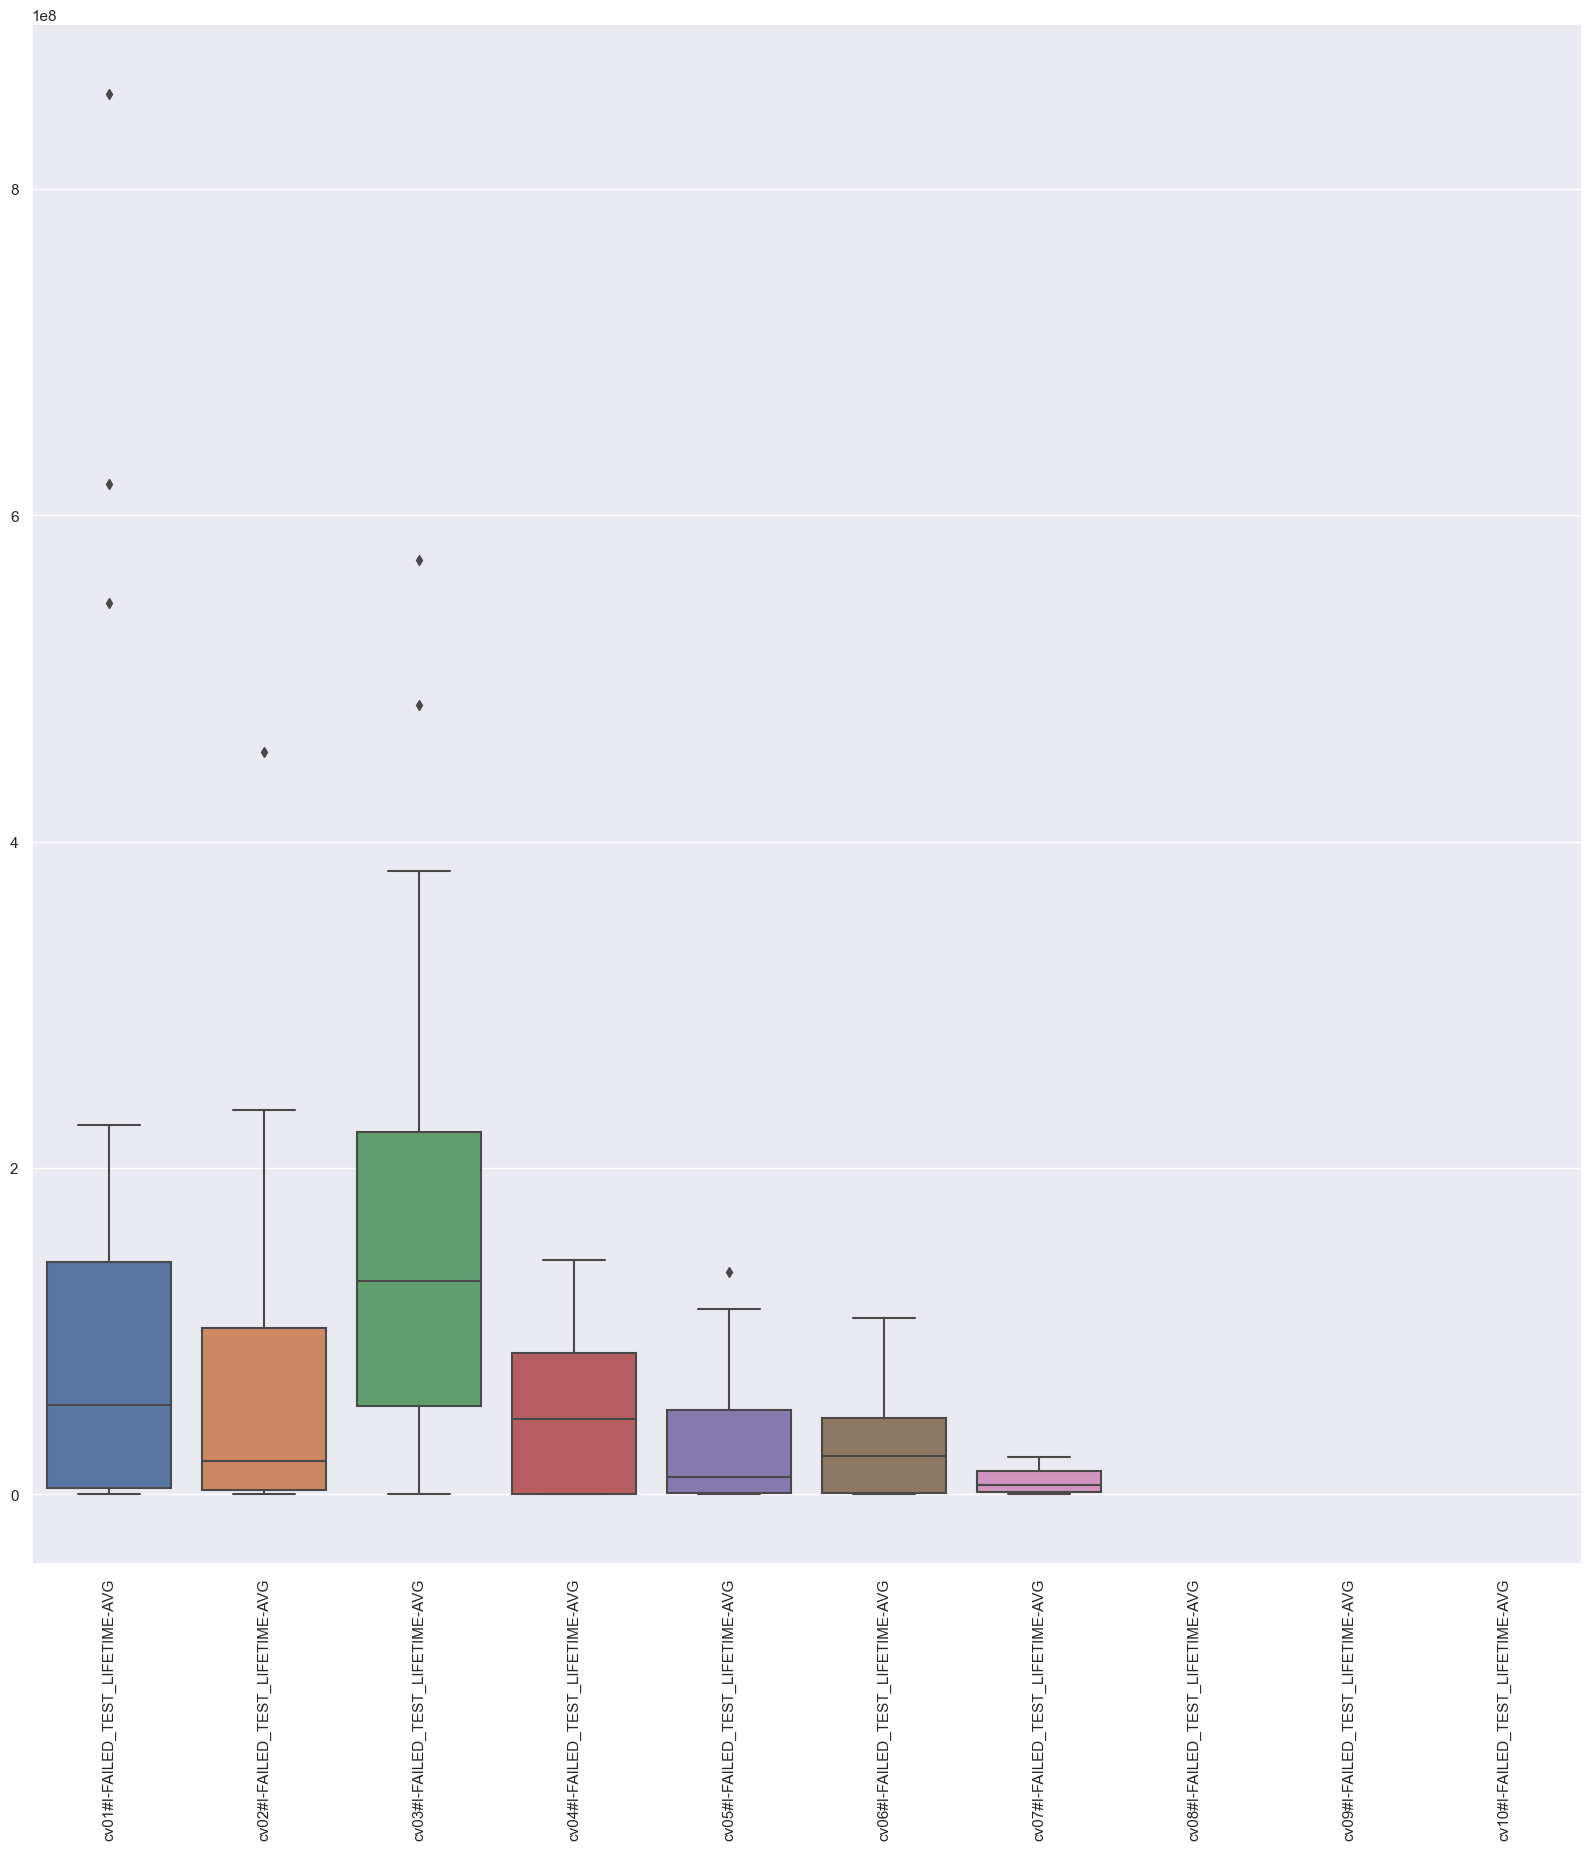

In [30]:
def showGraph(x):
    plt.figure(figsize=(20, 20))
    sns.boxplot(data=x)
    plt.xticks(rotation=90)

showGraph(x)

Save CSV

In [31]:
# I-FAILED_TEST_LIFETIME-AVG
# I-UNTESTED_TIME_BEFORE_EDIT-AVG
# I-UNTESTED_TIME_AFTER_EDIT-AVG
regexList = [ "I-FAILED_TEST_LIFETIME-AVG", "I-UNTESTED_TIME_BEFORE_EDIT-AVG", "I-UNTESTED_TIME_AFTER_EDIT-AVG"]
for regex in regexList:
    csvFileName = "./output/csv2/" + regex + ".csv"
    data = df.filter(regex=regex, axis=1)
    data.head()
    data.to_csv(csvFileName)